In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\hp\LOAN_DEFAULT_ANALYSIS\Cleaned_csv_file\Loan_default_clean.csv")

C:\Users\hp\AppData\Local\Temp\ipykernel_11864\4216590154.py:4: DtypeWarning: Columns (0: next_pymnt_d) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\Users\hp\LOAN_DEFAULT_ANALYSIS\Cleaned_csv_file\Loan_default_clean.csv")


Default Analysis

In [ ]:
Overall outcome distribution

In [5]:
df["default_status"].value_counts()

default_status
Did Not Default    1043940
Outcome Unknown     954281
Defaulted           262447
Name: count, dtype: int64

Outcome percentages

In [7]:
df["default_status"].value_counts(
    normalize=True
) * 100

default_status
Did Not Default    46.178386
Outcome Unknown    42.212346
Defaulted          11.609268
Name: proportion, dtype: float64

Visualize outcome distribution

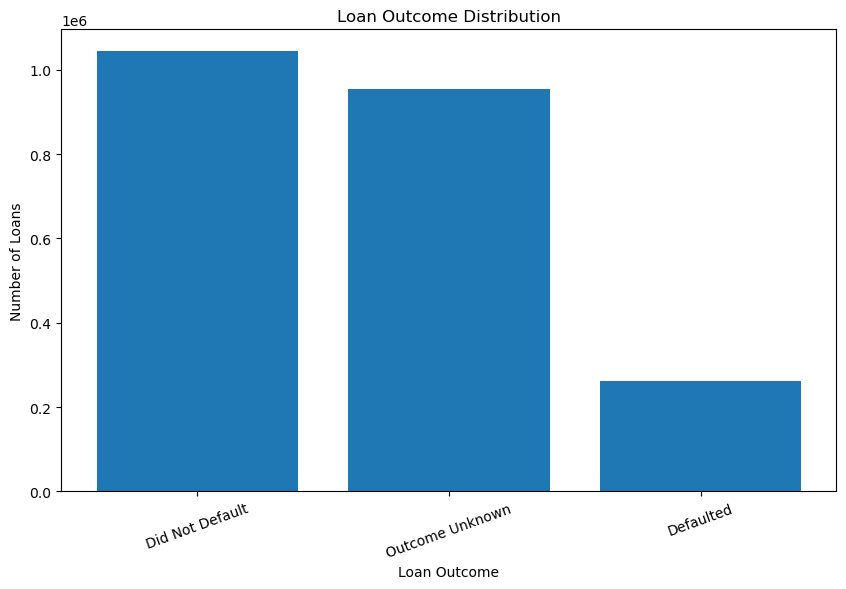

In [8]:
status_counts = df["default_status"].value_counts()

plt.figure(figsize=(10, 6))

plt.bar(
    status_counts.index,
    status_counts.values
)

plt.title("Loan Outcome Distribution")
plt.xlabel("Loan Outcome")
plt.ylabel("Number of Loans")

plt.xticks(rotation=20)

plt.show()

Finalized outcomes only

In [10]:
finalized_loans = df[
    df["default_status"].isin(
        ["Defaulted", "Did Not Default"]
    )
].copy()

In [11]:
finalized_loans["default_status"].value_counts()

default_status
Did Not Default    1043940
Defaulted           262447
Name: count, dtype: int64

Actual default rate

In [12]:
default_rate = (
    finalized_loans["default_status"]
    .eq("Defaulted")
    .mean()
    * 100
)

print("Default rate:", default_rate, "%")

Default rate: 20.089529366106675 %


Default rate by loan grade

In [14]:
grade_default = pd.crosstab(
    finalized_loans["grade"],
    finalized_loans["default_status"],
    normalize="index"
) * 100

grade_default

default_status,Defaulted,Did Not Default
grade,,
A,6.086338,93.913662
B,13.447145,86.552855
C,22.511240,77.488760
D,30.434894,69.565106
E,38.569102,61.430898
F,45.247699,54.752301
G,49.797704,50.202296


In [15]:
grade_default_rate = grade_default["Defaulted"]

print(grade_default_rate)

grade
A     6.086338
B    13.447145
C    22.511240
D    30.434894
E    38.569102
F    45.247699
G    49.797704
Name: Defaulted, dtype: float64


Visualize

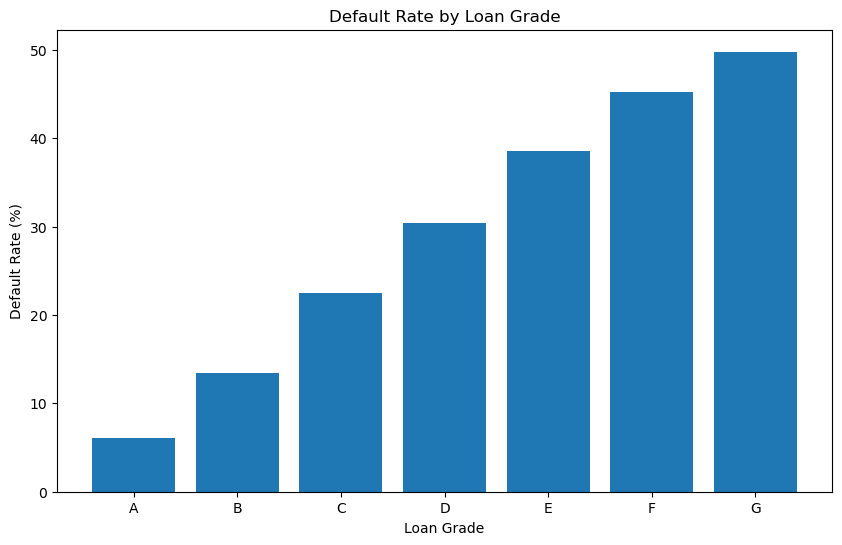

In [16]:
plt.figure(figsize=(10, 6))

plt.bar(
    grade_default_rate.index,
    grade_default_rate.values
)

plt.title("Default Rate by Loan Grade")
plt.xlabel("Loan Grade")
plt.ylabel("Default Rate (%)")

plt.show()

Default rate by loan purpose

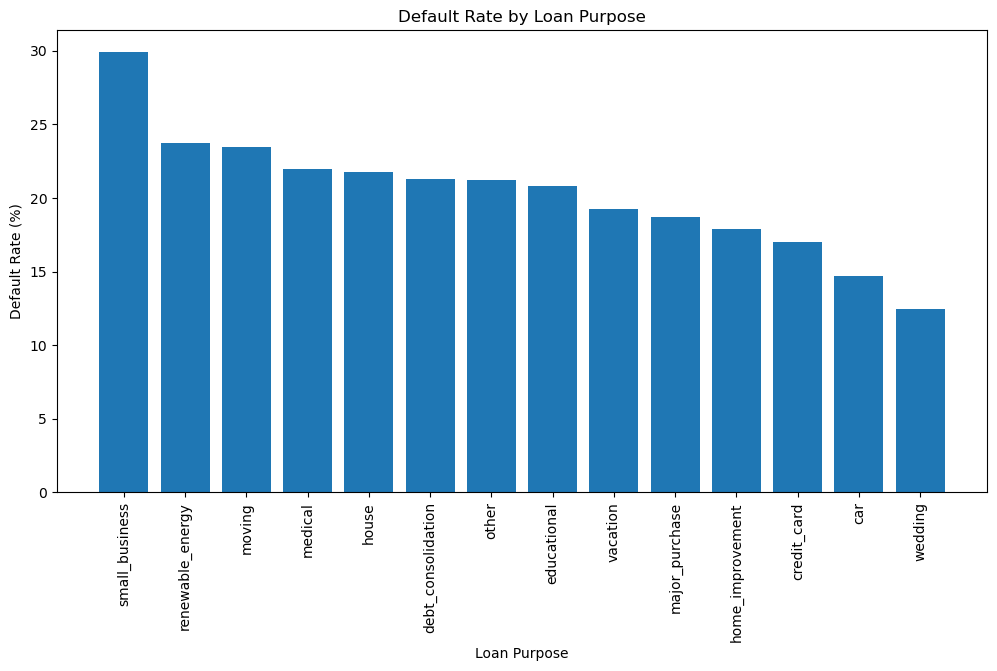

In [19]:
purpose_default = pd.crosstab(
    finalized_loans["purpose"],
    finalized_loans["default_status"],
    normalize="index"
) * 100

purpose_default_rate = purpose_default["Defaulted"].sort_values(
    ascending=False
)

plt.figure(figsize=(12, 6))

plt.bar(
    purpose_default_rate.index,
    purpose_default_rate.values
)

plt.title("Default Rate by Loan Purpose")
plt.xlabel("Loan Purpose")
plt.ylabel("Default Rate (%)")

plt.xticks(rotation=90)

plt.show()

Default rate by term

In [29]:
term_default = pd.crosstab(
    finalized_loans["term"],
    finalized_loans["default_status"],
    normalize="index"
) * 100

term_default

default_status,Defaulted,Did Not Default
term,,
36 months,16.123493,83.876507
60 months,32.562545,67.437455


Visualize

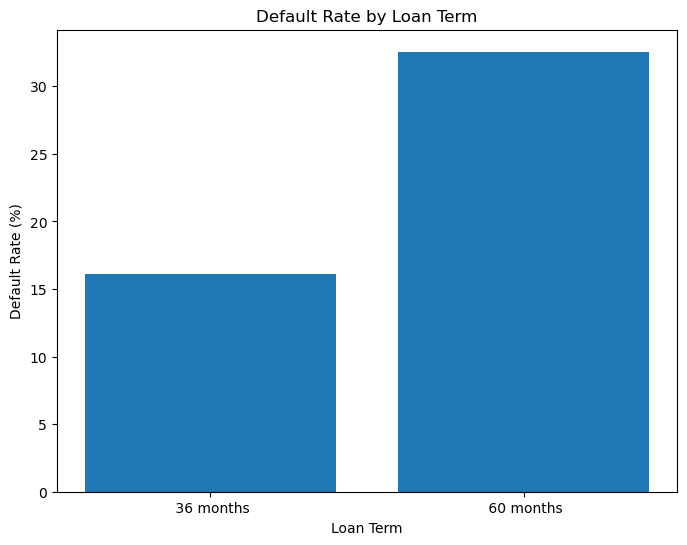

In [25]:
plt.figure(figsize=(8, 6))

plt.bar(
    term_default.index.astype(str),
    term_default["Defaulted"]
)

plt.title("Default Rate by Loan Term")
plt.xlabel("Loan Term")
plt.ylabel("Default Rate (%)")

plt.show()

Default rate by verification status

In [26]:
verification_default = pd.crosstab(
    finalized_loans["verification_status"],
    finalized_loans["default_status"],
    normalize="index"
) * 100

verification_default

default_status,Defaulted,Did Not Default
verification_status,,
Not Verified,14.773985,85.226015
Source Verified,21.123868,78.876132
Verified,23.942486,76.057514


Default rate by home ownership

In [30]:
home_default = pd.crosstab(
    finalized_loans["home_ownership"],
    finalized_loans["default_status"],
    normalize="index"
) * 100

home_default

default_status,Defaulted,Did Not Default
home_ownership,,
ANY,19.475655,80.524345
MORTGAGE,17.320511,82.679489
NONE,15.094340,84.905660
OTHER,20.879121,79.120879
OWN,20.755377,79.244623
RENT,23.360574,76.639426


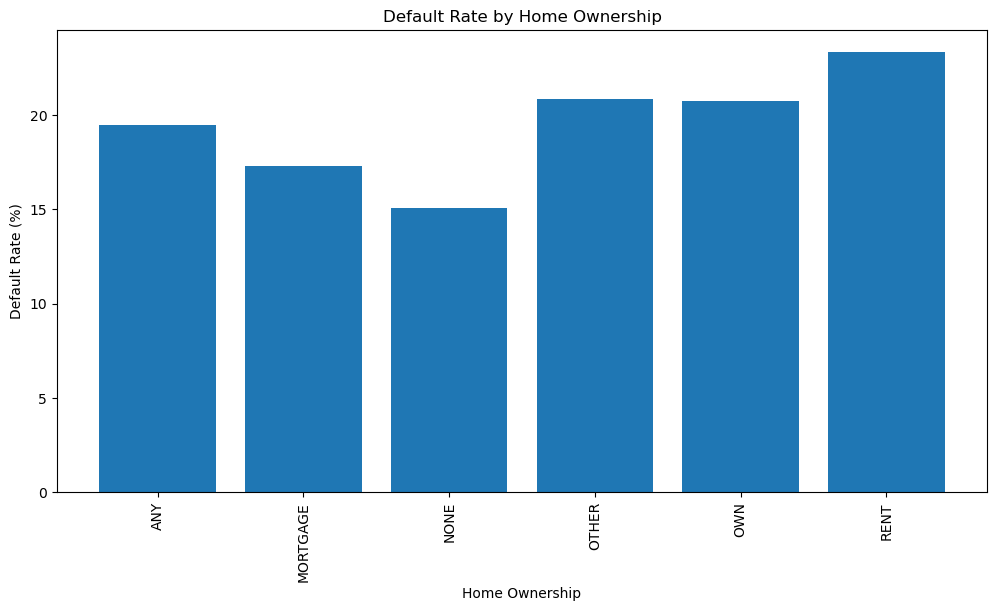

In [34]:
plt.figure(figsize=(12, 6))

plt.bar(
 home_default.index,
 home_default["Defaulted"]
)

plt.title("Default Rate by Home Ownership")
plt.xlabel("Home Ownership")
plt.ylabel("Default Rate (%)")

plt.xticks(rotation=90)

plt.show()